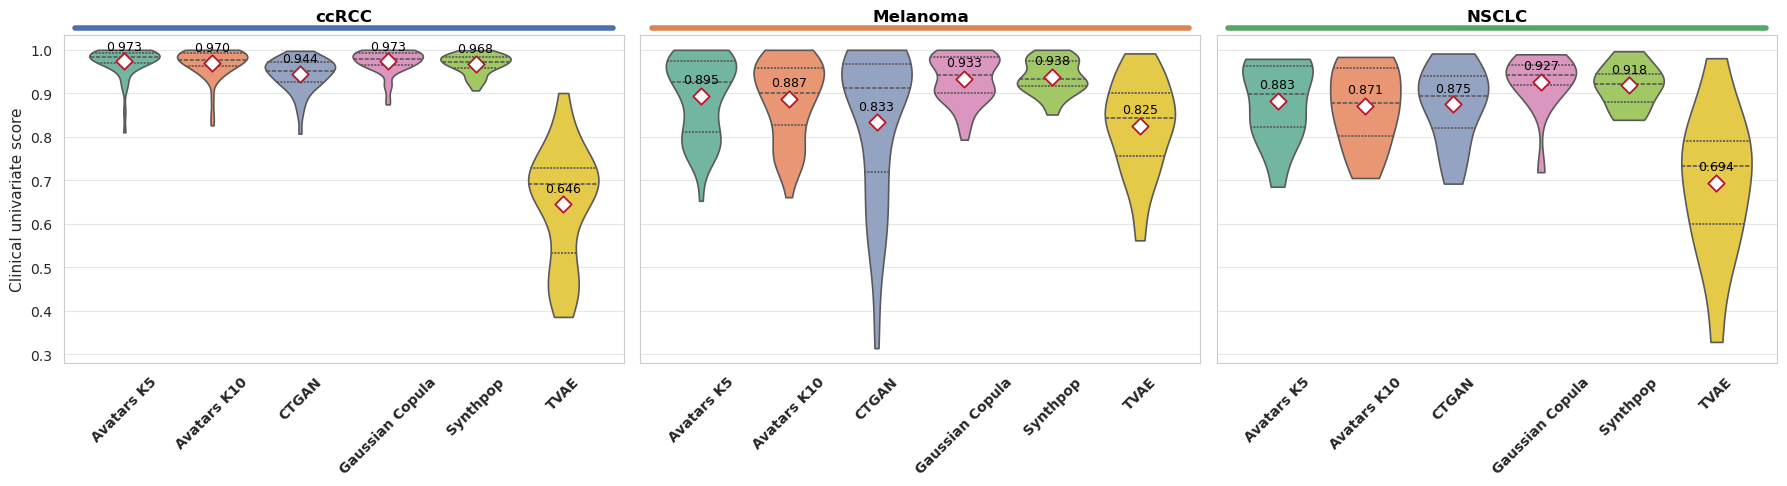

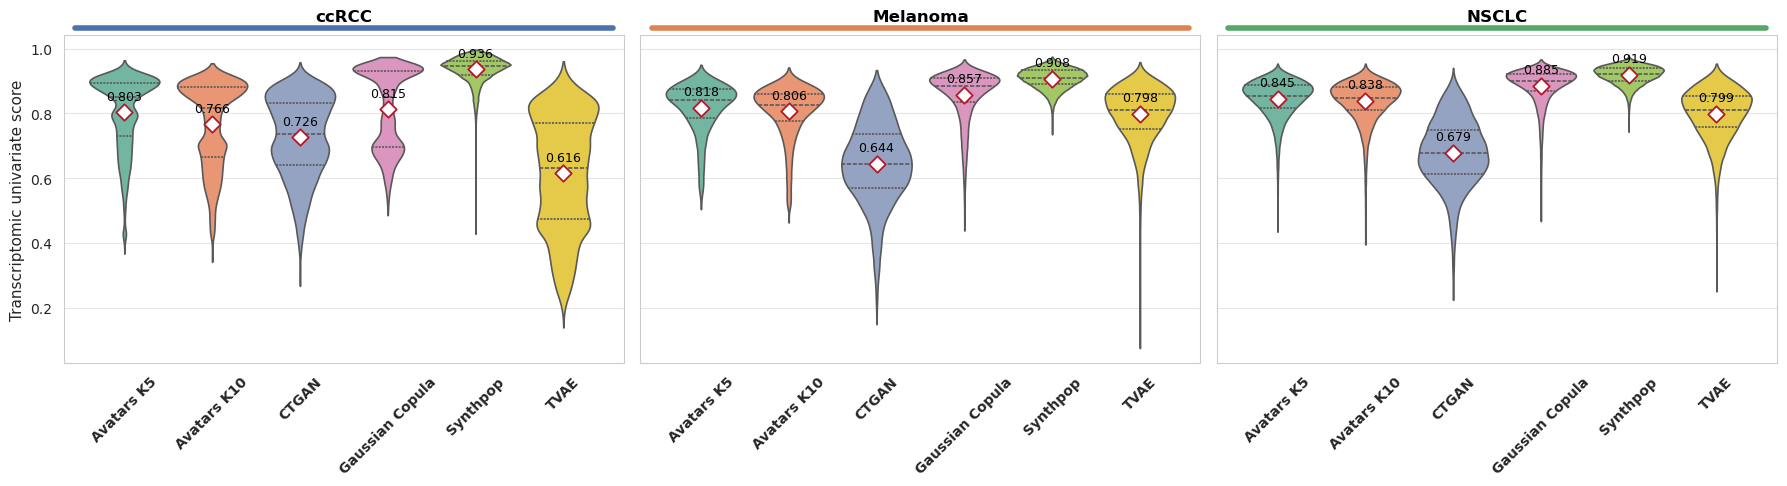

In [28]:
import pandas as pd
import numpy as np
from SynOmics.metrics.fidelity.visualization import plot_violin_grid_by_cancer
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

DATASET_COLORS = {
    "Avatars K5": "#66c2a5",         # greenish
    "Avatars K10": "#fc8d62",        # orange
    "CTGAN": "#8da0cb",              # blue
    "Gaussian Copula": "#e78ac3",    # pink
    "Synthpop": "#a6d854",           # lime
    "TVAE": "#ffd92f",               # yellow
}

seed = 42
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
cancers = ['ccRCC', 'Melanoma', 'NSCLC']

datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']

#Clinical features
Univariate_Score_Dict = {}

#Transcriptomic features
Univariate_OmicScore_Dict = {}

for cancer in cancers:
    score_dict = {}
    score_dict_omic = {}
    for i, dataset in enumerate(datasets):
        uni_score_df = pd.read_csv(f'../{cancer}/BroadUtility/UniClinicalSimi/UniClinicalSimi_{seed}/Detail_score_{dataset}.csv')
        uni_score_omic_df = pd.read_csv(f'../{cancer}/BroadUtility/UniTranscriptomicsSimi/UniTranscriptomicsSimi_{seed}/Detail_score_{dataset}.csv')
        score = uni_score_df['Score'].fillna(0).tolist()
        score_omic = uni_score_omic_df['Score'].fillna(0).tolist()
        score_dict[names[i]]=score 
        score_dict_omic[names[i]]=score_omic 
        
    Univariate_Score_Dict[cancer]=score_dict
    Univariate_OmicScore_Dict[cancer] = score_dict_omic


#Visualization
#Clinical features
fig, axes, mean_by_cancer = plot_violin_grid_by_cancer(
    cancer_to_method_scores=Univariate_Score_Dict,
    value_name="Clinical univariate score", 
    methods_order=names,
    palette=DATASET_COLORS,  
    figsize=(18, 5),          
    fontsize=11,
    annotate_mean=True,      
    show=True,
)
fig.savefig(f"figure2a_univariate/clinical_uni_{seed}.pdf", bbox_inches="tight", facecolor="white")


#Transcriptomic features
fig_omic, axes, mean_by_cancer = plot_violin_grid_by_cancer(
    cancer_to_method_scores=Univariate_OmicScore_Dict,
    value_name="Transcriptomic univariate score", 
    methods_order=names,
    palette=DATASET_COLORS,  
    figsize=(18, 5),          
    fontsize=11,
    annotate_mean=True,      
    show=True,
)

fig_omic.savefig(f"figure2a_univariate/omic_uni_{seed}.pdf", bbox_inches="tight", facecolor="white")